# CSI300 Image Rendering Sensitivity Study

This notebook studies **how different image drawing choices affect prediction and timing performance** for the CSI300 index.

## Goal
Keep the **data, labels, train/validation/test split, and 2D CNN architecture fixed**, and only change the **image rendering method**.  
This lets us isolate whether performance differences come from the **image representation itself**.

## Main comparison directions
1. **OHLC-only vs OHLC+MA vs OHLC+MA+Volume**
2. **OHLC bars vs candlestick body**
3. **Image resolution** (e.g. 48, 64, 96)
4. **Volume area ratio** (e.g. bottom 20% vs 30%)
5. **Price normalization method** inside each rolling window

## Output
For each rendering variant, we will report:
- validation / test accuracy
- annual return
- annual volatility
- Sharpe ratio
- max drawdown
- timing strategy NAV vs HS300 buy-and-hold

In [12]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# Set random seeds for reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [13]:
# ============================================================
# 1. Imports and random seed
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed fixed:", SEED)

TensorFlow version: 2.21.0
Random seed fixed: 42


## Data assumption

This notebook assumes you already have:
- merged daily file: `CSI300_merged_2005_2026.csv`
- rolling-window file with **OHLC + volume + ma20** features

If you do not yet have the rolling-window file with volume and MA, the next cell will build it from the merged CSV.

In [14]:
# ============================================================
# 2. Build rolling-window dataset with OHLC + volume + ma20
# ============================================================
folder_path = "."
price_file = os.path.join(folder_path, "CSI300_merged_2005_2026.csv")
npz_file = os.path.join(folder_path, "CSI300_window20_label5d_ohlc_volume_ma.npz")

WINDOW = 20
HORIZON = 5

if not os.path.exists(npz_file):
    df = pd.read_csv(price_file)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    # create ma20
    df["ma20"] = df["close"].rolling(20).mean()

    # keep needed columns
    df = df[["date", "open", "high", "low", "close", "volume", "ma20"]].copy()

    # label: future 5-day return > 0
    df["future_5d_ret"] = df["close"].shift(-HORIZON) / df["close"] - 1
    df["label_5d"] = (df["future_5d_ret"] > 0).astype(int)

    # drop rows where ma20 is not available
    df = df.dropna(subset=["ma20"]).reset_index(drop=True)

    feature_cols = ["open", "high", "low", "close", "volume", "ma20"]

    X, y, dates = [], [], []
    for i in range(WINDOW - 1, len(df) - HORIZON):
        window_data = df.loc[i-WINDOW+1:i, feature_cols].values
        label = df.loc[i, "label_5d"]
        sample_date = df.loc[i, "date"]
        X.append(window_data)
        y.append(label)
        dates.append(sample_date)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    dates = np.array(dates).astype(str)

    np.savez(npz_file, X=X, y=y, dates=dates)
    print("Saved:", npz_file)
else:
    print("Existing dataset found:", npz_file)

Existing dataset found: /Users/daijinyang/Desktop/HS300/CSI300_window20_label5d_ohlc_volume_ma.npz


In [15]:
# ============================================================
# 3. Load rolling-window dataset
# ============================================================
data = np.load(npz_file, allow_pickle=True)
X = data["X"]      # shape: (n_samples, 20, 6)
y = data["y"]
dates = data["dates"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("dates shape:", dates.shape)

# time-based split
n = len(X)
train_end = int(n * 0.6)
valid_end = int(n * 0.8)

X_train = X[:train_end]
y_train = y[:train_end]

X_valid = X[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test = X[valid_end:]
y_test = y[valid_end:]

dates_train = dates[:train_end]
dates_valid = dates[train_end:valid_end]
dates_test = dates[valid_end:]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)
print("Train period:", dates_train[0], "to", dates_train[-1])
print("Valid period:", dates_valid[0], "to", dates_valid[-1])
print("Test  period:", dates_test[0], "to", dates_test[-1])

X shape: (5114, 20, 6)
y shape: (5114,)
dates shape: (5114,)
Train: (3068, 20, 6) (3068,)
Valid: (1023, 20, 6) (1023,)
Test : (1023, 20, 6) (1023,)
Train period: 2005-03-08 00:00:00 to 2017-10-17 00:00:00
Valid period: 2017-10-18 00:00:00 to 2021-12-28 00:00:00
Test  period: 2021-12-29 00:00:00 to 2026-03-24 00:00:00


## Backtest helper functions

In [16]:
# ============================================================
# 4. Backtest and performance functions
# ============================================================
def annualized_return(ret_series, periods_per_year=244):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return np.nan
    nav = (1 + ret_series).prod()
    return nav ** (periods_per_year / len(ret_series)) - 1

def annualized_volatility(ret_series, periods_per_year=244):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return np.nan
    return ret_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret_series, periods_per_year=244, rf=0):
    ann_ret = annualized_return(ret_series, periods_per_year)
    ann_vol = annualized_volatility(ret_series, periods_per_year)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return (ann_ret - rf) / ann_vol

def max_drawdown(nav_series):
    nav_series = pd.Series(nav_series).dropna()
    if len(nav_series) == 0:
        return np.nan
    rolling_max = nav_series.cummax()
    drawdown = nav_series / rolling_max - 1
    return drawdown.min()

def backtest_from_prob(dates_test, y_test_prob, threshold=0.5,
                       price_file=price_file, horizon=5):
    """
    Scheme A backtest used in this notebook:
    - the model generates a raw signal on sample date t,
    - if the strategy enters, it holds the index for the next 5 trading days,
    - all new signals are ignored during those 5 holding days.
    """
    signal_df = pd.DataFrame({
        "date": pd.to_datetime(dates_test),
        "y_prob": y_test_prob
    }).sort_values("date").reset_index(drop=True)
    signal_df["raw_signal"] = (signal_df["y_prob"] > threshold).astype(int)

    px = pd.read_csv(price_file)
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").reset_index(drop=True)
    px["ret_1d"] = px["close"].pct_change()

    date_to_idx = {pd.Timestamp(d): i for i, d in enumerate(px["date"])}
    positions = np.zeros(len(px), dtype=int)

    used_signals = []
    ignored_signals = []
    active_until_idx = -1

    for _, row in signal_df.iterrows():
        signal_date = pd.Timestamp(row["date"])
        raw_signal = int(row["raw_signal"])
        idx = date_to_idx.get(signal_date)

        if idx is None or idx + horizon >= len(px):
            used_signals.append(0)
            ignored_signals.append(0)
            continue

        if idx < active_until_idx:
            used_signals.append(0)
            ignored_signals.append(1)
            continue

        if raw_signal == 1:
            positions[idx + 1: idx + horizon + 1] = 1
            active_until_idx = idx + horizon
            used_signals.append(1)
            ignored_signals.append(0)
        else:
            used_signals.append(0)
            ignored_signals.append(0)

    signal_df["used_signal"] = used_signals
    signal_df["ignored_signal"] = ignored_signals

    valid_signal_dates = signal_df["date"].map(date_to_idx).dropna().astype(int)
    if len(valid_signal_dates) == 0:
        raise ValueError("No test dates were matched to the price file.")

    start_idx = int(valid_signal_dates.iloc[0]) + 1
    end_idx = min(int(valid_signal_dates.iloc[-1]) + horizon, len(px) - 1)

    result_df = px.loc[start_idx:end_idx, ["date", "ret_1d"]].copy().reset_index(drop=True)
    result_df["signal"] = positions[start_idx:end_idx + 1]
    result_df["strategy_ret"] = result_df["signal"] * result_df["ret_1d"]
    result_df["buy_hold_ret"] = result_df["ret_1d"]

    result_df["strategy_nav"] = (1 + result_df["strategy_ret"]).cumprod()
    result_df["buy_hold_nav"] = (1 + result_df["buy_hold_ret"]).cumprod()

    summary = {
        "Annual Return": annualized_return(result_df["strategy_ret"]),
        "Annual Vol": annualized_volatility(result_df["strategy_ret"]),
        "Sharpe": sharpe_ratio(result_df["strategy_ret"]),
        "Max Drawdown": max_drawdown(result_df["strategy_nav"]),
        "BuyHold Annual Return": annualized_return(result_df["buy_hold_ret"]),
        "BuyHold Annual Vol": annualized_volatility(result_df["buy_hold_ret"]),
        "BuyHold Sharpe": sharpe_ratio(result_df["buy_hold_ret"]),
        "BuyHold Max Drawdown": max_drawdown(result_df["buy_hold_nav"]),
        "Average Exposure": result_df["signal"].mean(),
        "Used Signal Ratio": signal_df["used_signal"].mean(),
        "Ignored Signal Ratio": signal_df["ignored_signal"].mean()
    }
    return result_df, summary, signal_df

def plot_strategy_vs_hs300_visible(result_df, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(result_df["date"], result_df["buy_hold_nav"],
             label="HS300 Buy-and-Hold", linewidth=3, alpha=0.85, zorder=1)
    plt.plot(result_df["date"], result_df["strategy_nav"],
             label=f"{model_name} Timing Strategy",
             linewidth=1.8, linestyle="--", marker="o", markersize=2,
             markevery=max(1, len(result_df)//40), zorder=3)
    plt.title(f"{model_name} vs HS300 Buy-and-Hold (5-Day Silent Holding Rule)")
    plt.xlabel("Date")
    plt.ylabel("Net Asset Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(result_df["date"],
             result_df["strategy_nav"] - result_df["buy_hold_nav"],
             linewidth=1.5)
    plt.axhline(0, color="black", linestyle="--")
    plt.title(f"{model_name}: Strategy NAV - HS300 NAV")
    plt.xlabel("Date")
    plt.ylabel("NAV Difference")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Rendering variants

Below we define several image-drawing choices.

### Planned variants
- **V1_OHLC**: OHLC bars only
- **V2_OHLC_MA**: OHLC bars + MA20 line
- **V3_OHLC_MA_VOL**: OHLC bars + MA20 + volume bars
- **V4_CANDLE_MA_VOL**: candlestick body + wick + MA20 + volume
- **V5_HIGHRES_OHLC_MA_VOL**: same as V3 but higher image resolution
- **V6_VOL30_OHLC_MA_VOL**: same as V3 but allocate more image space to volume

In [17]:
# ============================================================
# 5. Image rendering functions
# ============================================================
def _scale_price_to_y(price, max_price, min_price, price_h):
    if max_price == min_price:
        max_price += 1e-6
    y = int(round((max_price - price) / (max_price - min_price) * (price_h - 1)))
    return int(np.clip(y, 0, price_h - 1))

def render_ohlc_image(window, height=64, include_ma=False, include_volume=False,
                      volume_ratio=0.2):
    '''
    window columns = [open, high, low, close, volume, ma20]
    '''
    n_days = window.shape[0]
    width = n_days * 3
    img = np.zeros((height, width), dtype=np.uint8)

    price_h = int(height * (1 - volume_ratio)) if include_volume else height
    vol_h = height - price_h if include_volume else 0

    open_ = window[:, 0]
    high_ = window[:, 1]
    low_  = window[:, 2]
    close_= window[:, 3]
    vol_  = window[:, 4]
    ma20_ = window[:, 5]

    max_price = np.max(high_)
    min_price = np.min(low_)
    max_vol = np.max(vol_) if np.max(vol_) > 0 else 1e-6

    ma_points = []

    for i in range(n_days):
        x0 = i * 3
        o, h, l, c = open_[i], high_[i], low_[i], close_[i]

        y_open  = _scale_price_to_y(o, max_price, min_price, price_h)
        y_high  = _scale_price_to_y(h, max_price, min_price, price_h)
        y_low   = _scale_price_to_y(l, max_price, min_price, price_h)
        y_close = _scale_price_to_y(c, max_price, min_price, price_h)

        # high-low wick
        img[min(y_high, y_low):max(y_high, y_low)+1, x0+1] = 255
        # open and close ticks
        img[y_open, x0] = 255
        img[y_close, x0+2] = 255

        if include_ma:
            y_ma = _scale_price_to_y(ma20_[i], max_price, min_price, price_h)
            ma_points.append((x0 + 1, y_ma))

        if include_volume and vol_h > 0:
            bar_h = int(round(vol_[i] / max_vol * max(1, vol_h - 1)))
            if bar_h > 0:
                img[price_h + (vol_h - bar_h):height, x0:x0+3] = 180

    if include_ma and len(ma_points) >= 2:
        for i in range(1, len(ma_points)):
            x1, y1 = ma_points[i-1]
            x2, y2 = ma_points[i]
            n = max(abs(x2 - x1), abs(y2 - y1)) + 1
            xs = np.linspace(x1, x2, n).astype(int)
            ys = np.linspace(y1, y2, n).astype(int)
            img[ys, xs] = 220
    return img

def render_candlestick_image(window, height=64, include_ma=True, include_volume=True,
                             volume_ratio=0.2):
    '''
    Candlestick body + wick + MA20 + volume
    '''
    n_days = window.shape[0]
    width = n_days * 3
    img = np.zeros((height, width), dtype=np.uint8)

    price_h = int(height * (1 - volume_ratio)) if include_volume else height
    vol_h = height - price_h if include_volume else 0

    open_ = window[:, 0]
    high_ = window[:, 1]
    low_  = window[:, 2]
    close_= window[:, 3]
    vol_  = window[:, 4]
    ma20_ = window[:, 5]

    max_price = np.max(high_)
    min_price = np.min(low_)
    max_vol = np.max(vol_) if np.max(vol_) > 0 else 1e-6

    ma_points = []

    for i in range(n_days):
        x0 = i * 3
        o, h, l, c = open_[i], high_[i], low_[i], close_[i]

        y_open  = _scale_price_to_y(o, max_price, min_price, price_h)
        y_high  = _scale_price_to_y(h, max_price, min_price, price_h)
        y_low   = _scale_price_to_y(l, max_price, min_price, price_h)
        y_close = _scale_price_to_y(c, max_price, min_price, price_h)

        # wick
        img[min(y_high, y_low):max(y_high, y_low)+1, x0+1] = 255

        # body
        top = min(y_open, y_close)
        bottom = max(y_open, y_close)
        body_intensity = 220 if c >= o else 140
        img[top:bottom+1, x0:x0+3] = body_intensity

        if include_ma:
            y_ma = _scale_price_to_y(ma20_[i], max_price, min_price, price_h)
            ma_points.append((x0 + 1, y_ma))

        if include_volume and vol_h > 0:
            bar_h = int(round(vol_[i] / max_vol * max(1, vol_h - 1)))
            if bar_h > 0:
                img[price_h + (vol_h - bar_h):height, x0:x0+3] = 180

    if include_ma and len(ma_points) >= 2:
        for i in range(1, len(ma_points)):
            x1, y1 = ma_points[i-1]
            x2, y2 = ma_points[i]
            n = max(abs(x2 - x1), abs(y2 - y1)) + 1
            xs = np.linspace(x1, x2, n).astype(int)
            ys = np.linspace(y1, y2, n).astype(int)
            img[ys, xs] = 255
    return img

In [18]:
# ============================================================
# 6. Build image dataset for each variant
# ============================================================
def build_image_dataset(X, variant_name):
    if variant_name == "V1_OHLC":
        imgs = [render_ohlc_image(x, height=64, include_ma=False, include_volume=False)
                for x in X]
    elif variant_name == "V2_OHLC_MA":
        imgs = [render_ohlc_image(x, height=64, include_ma=True, include_volume=False)
                for x in X]
    elif variant_name == "V3_OHLC_MA_VOL":
        imgs = [render_ohlc_image(x, height=64, include_ma=True, include_volume=True, volume_ratio=0.2)
                for x in X]
    elif variant_name == "V4_CANDLE_MA_VOL":
        imgs = [render_candlestick_image(x, height=64, include_ma=True, include_volume=True, volume_ratio=0.2)
                for x in X]
    elif variant_name == "V5_HIGHRES_OHLC_MA_VOL":
        imgs = [render_ohlc_image(x, height=96, include_ma=True, include_volume=True, volume_ratio=0.2)
                for x in X]
    elif variant_name == "V6_VOL30_OHLC_MA_VOL":
        imgs = [render_ohlc_image(x, height=64, include_ma=True, include_volume=True, volume_ratio=0.3)
                for x in X]
    else:
        raise ValueError(f"Unknown variant: {variant_name}")

    imgs = np.array(imgs, dtype=np.float32) / 255.0
    imgs = imgs[..., np.newaxis]
    return imgs

## Preview sample images for each rendering variant

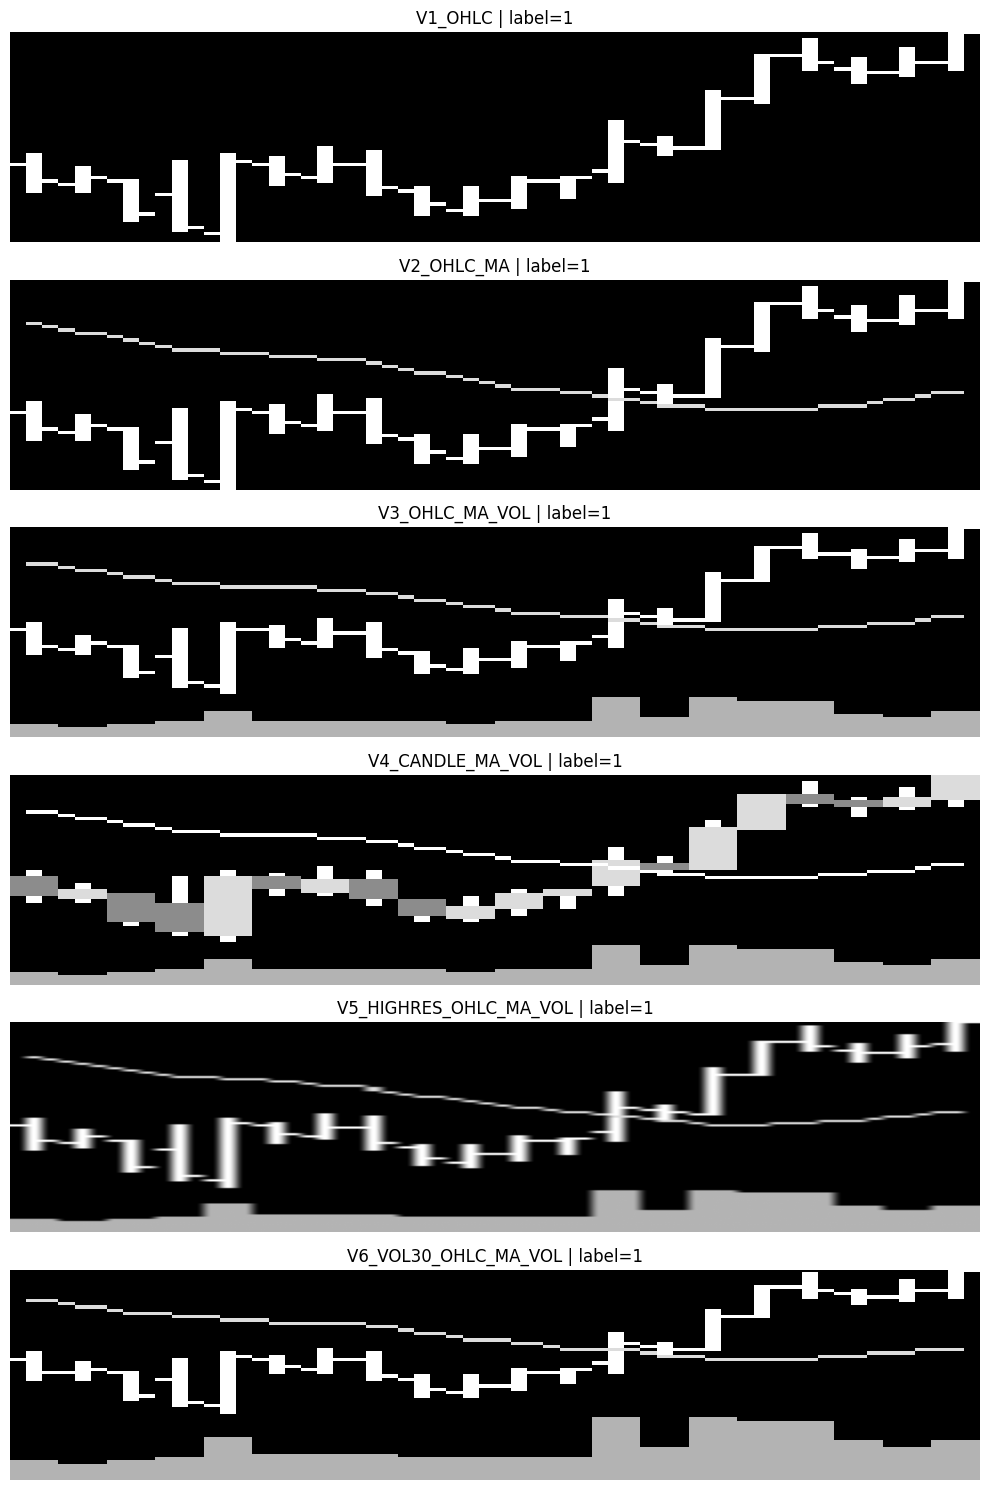

In [19]:
# ============================================================
# 7. Visual check of different rendering methods
# ============================================================
variants = [
    "V1_OHLC",
    "V2_OHLC_MA",
    "V3_OHLC_MA_VOL",
    "V4_CANDLE_MA_VOL",
    "V5_HIGHRES_OHLC_MA_VOL",
    "V6_VOL30_OHLC_MA_VOL"
]

sample_idx = 100

fig, axes = plt.subplots(len(variants), 1, figsize=(10, 2.5 * len(variants)))
for ax, v in zip(axes, variants):
    img = build_image_dataset(X_train[sample_idx:sample_idx+1], v)[0].squeeze()
    ax.imshow(img, cmap="gray", aspect="auto")
    ax.set_title(f"{v} | label={y_train[sample_idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Shared 2D CNN

To isolate the effect of image rendering, we keep the CNN architecture and training setup aligned with the **Stronger 2D CNN** notebook.

In [20]:
# ============================================================
# 8. Shared 2D CNN architecture (identical to Stronger 2D CNN)
# ============================================================
def make_2dcnn(input_shape, learning_rate=5e-4):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.15),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.20),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(256, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        GlobalAveragePooling2D(),

        Dense(128, activation="relu"),
        Dropout(0.30),
        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


## Single-variant training function

In [21]:
# ============================================================
# 9. Train + evaluate one rendering variant
# ============================================================
def train_variant(variant_name, threshold=0.5, epochs=100, batch_size=32, verbose=1):
    print("=" * 80)
    print("Training variant:", variant_name)

    # Fix the random seed so that the training setup stays aligned with the Stronger 2D CNN notebook.
    import random
    SEED = 42
    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    tf.keras.utils.set_random_seed(SEED)

    X_train_img = build_image_dataset(X_train, variant_name)
    X_valid_img = build_image_dataset(X_valid, variant_name)
    X_test_img  = build_image_dataset(X_test,  variant_name)

    model = make_2dcnn(X_train_img.shape[1:])

    checkpoint_path = os.path.join(folder_path, f"best_{variant_name}_stronger.keras")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        X_train_img, y_train,
        validation_data=(X_valid_img, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=verbose
    )

    y_valid_prob = model.predict(X_valid_img, verbose=0).ravel()
    y_valid_pred = (y_valid_prob > 0.5).astype(int)

    y_test_prob = model.predict(X_test_img, verbose=0).ravel()
    y_test_pred = (y_test_prob > 0.5).astype(int)

    bt_df, bt_summary, signal_df = backtest_from_prob(dates_test, y_test_prob, threshold=threshold)

    row = {
        "Variant": variant_name,
        "Validation Accuracy": accuracy_score(y_valid, y_valid_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Annual Return": bt_summary["Annual Return"],
        "Annual Vol": bt_summary["Annual Vol"],
        "Sharpe": bt_summary["Sharpe"],
        "Max Drawdown": bt_summary["Max Drawdown"],
        "Average Exposure": bt_df["signal"].mean()
    }

    return model, history, bt_df, row


## Run all rendering experiments

In [23]:
# ============================================================
# 10. Run all variants
# ============================================================
results = []
backtests = {}
histories = {}
models = {}

for v in variants:
    model, history, bt_df, row = train_variant(
        v,
        threshold=0.5,
        epochs=100,
        batch_size=32,
        verbose=1
    )
    models[v] = model
    histories[v] = history
    backtests[v] = bt_df
    results.append(row)

summary_df = pd.DataFrame(results).sort_values(
    by=["Sharpe", "Annual Return", "Test Accuracy"],
    ascending=False
).reset_index(drop=True)

summary_df

Training variant: V1_OHLC
Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5292 - loss: 0.6897
Epoch 1: val_loss improved from None to 0.86028, saving model to /Users/daijinyang/Desktop/HS300/best_V1_OHLC_stronger.keras

Epoch 1: finished saving model to /Users/daijinyang/Desktop/HS300/best_V1_OHLC_stronger.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.5391 - loss: 0.6886 - val_accuracy: 0.5474 - val_loss: 0.8603 - learning_rate: 5.0000e-04
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5432 - loss: 0.6839
Epoch 2: val_loss improved from 0.86028 to 0.78963, saving model to /Users/daijinyang/Desktop/HS300/best_V1_OHLC_stronger.keras

Epoch 2: finished saving model to /Users/daijinyang/Desktop/HS300/best_V1_OHLC_stronger.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.5398 - loss: 0.6877 - val_accuracy: 0.5474 - val_loss: 0.7896 - learning_rate: 5.0000e-04
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 

,Variant,Validation Accuracy,Test Accuracy,Annual Return,Annual Vol,Sharpe,Max Drawdown,Average Exposure
0,V2_OHLC_MA,0.467253,0.499511,0.024661,0.130452,0.189046,-0.183108,0.569620
1,V5_HIGHRES_OHLC_MA_VOL,0.506354,0.494624,0.012219,0.168664,0.072444,-0.333925,0.939630
2,V1_OHLC,0.547410,0.477028,-0.019109,0.175182,-0.109082,-0.360525,0.998053
3,V3_OHLC_MA_VOL,0.547410,0.477028,-0.019109,0.175182,-0.109082,-0.360525,0.998053
4,V4_CANDLE_MA_VOL,0.547410,0.477028,-0.019109,0.175182,-0.109082,-0.360525,0.998053
5,V6_VOL30_OHLC_MA_VOL,0.547410,0.477028,-0.019109,0.175182,-0.109082,-0.360525,0.998053


## Plot timing strategy vs HS300 for each rendering variant


 ############################## V1_OHLC ##############################


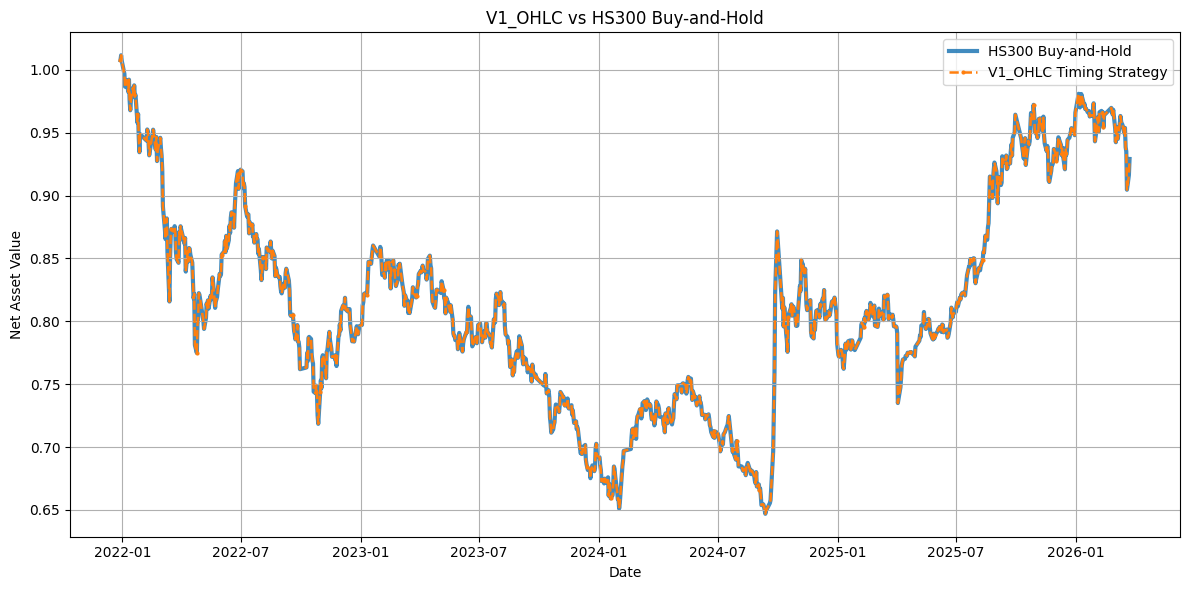

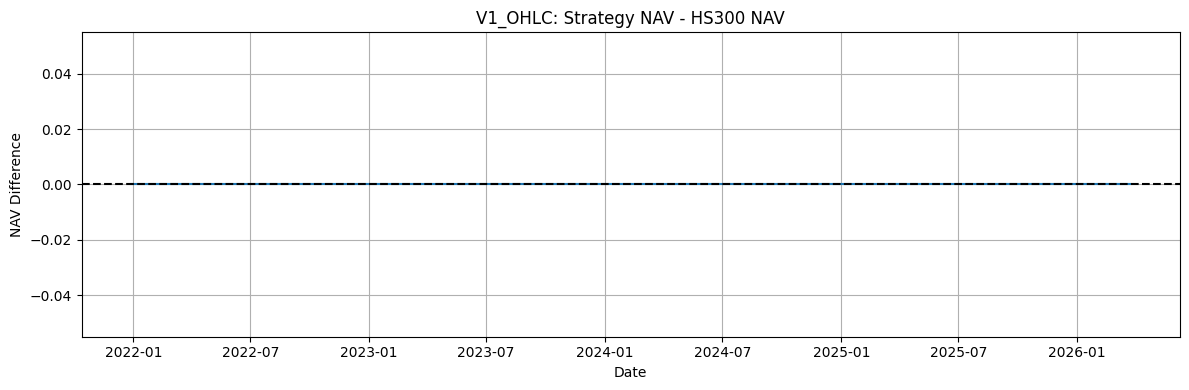


 ############################## V2_OHLC_MA ##############################


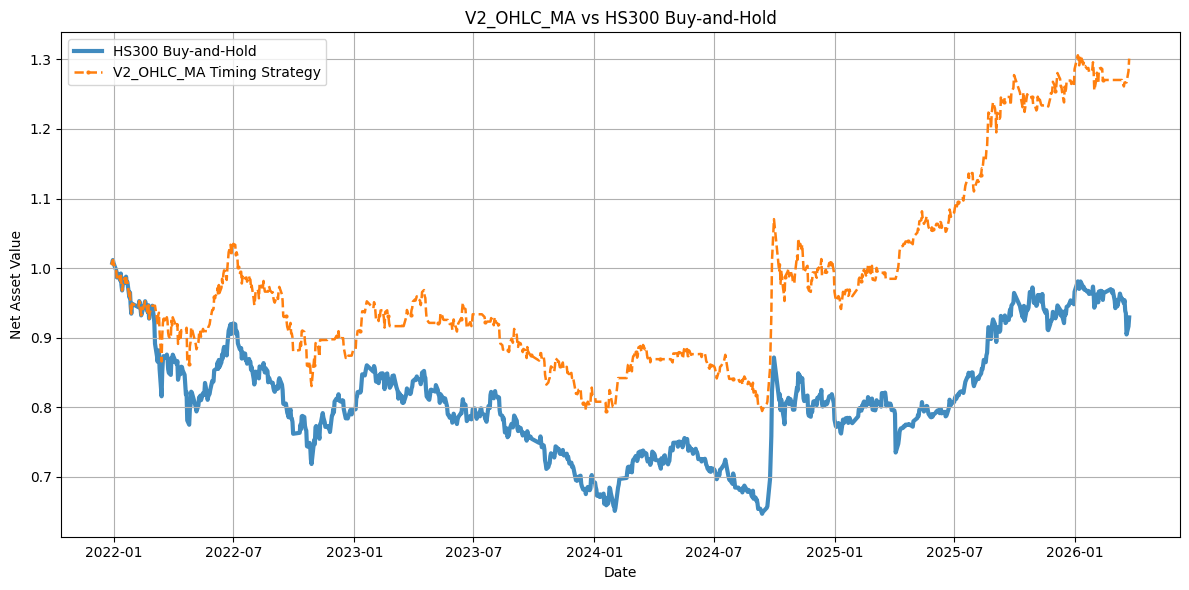

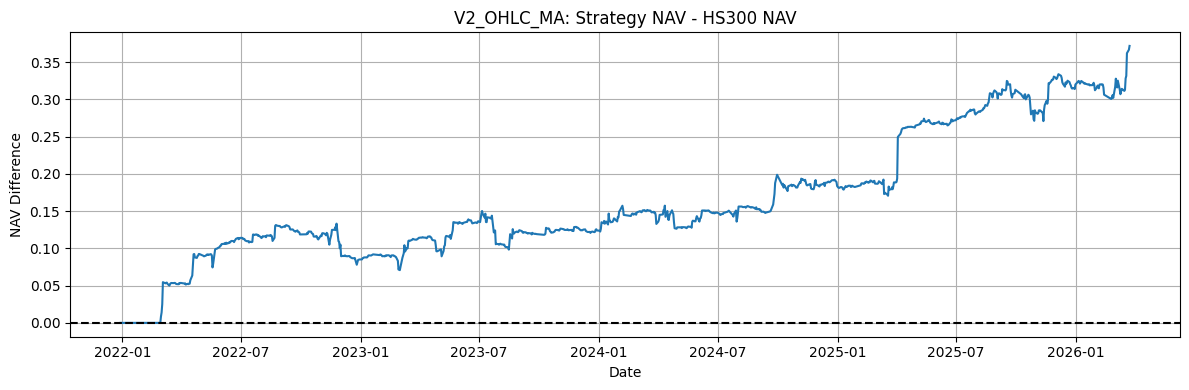


 ############################## V3_OHLC_MA_VOL ##############################


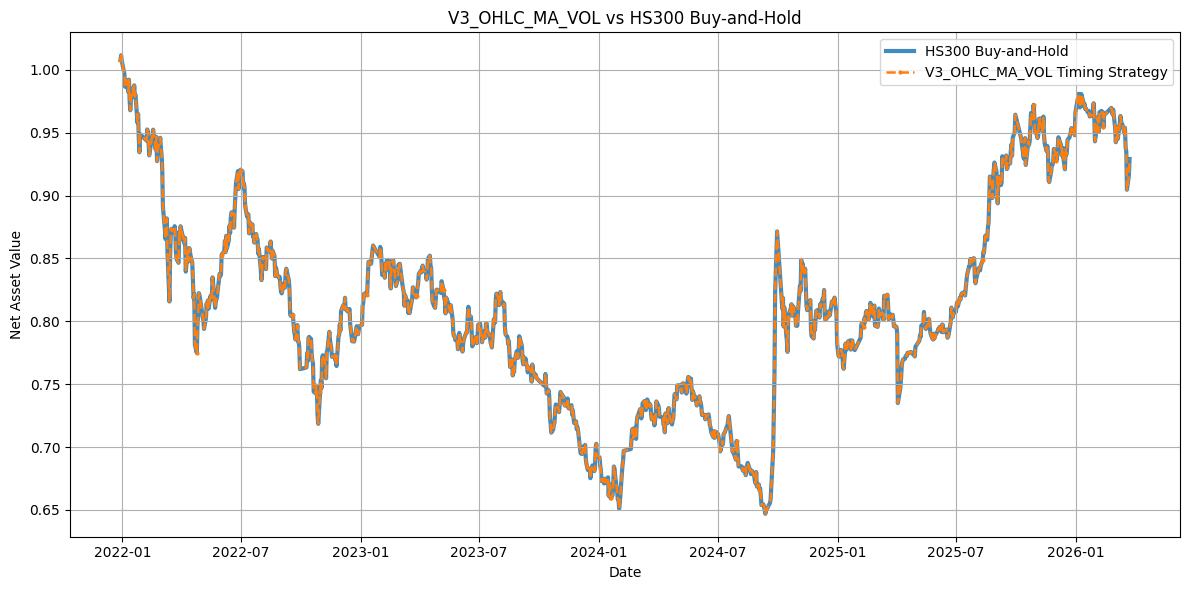

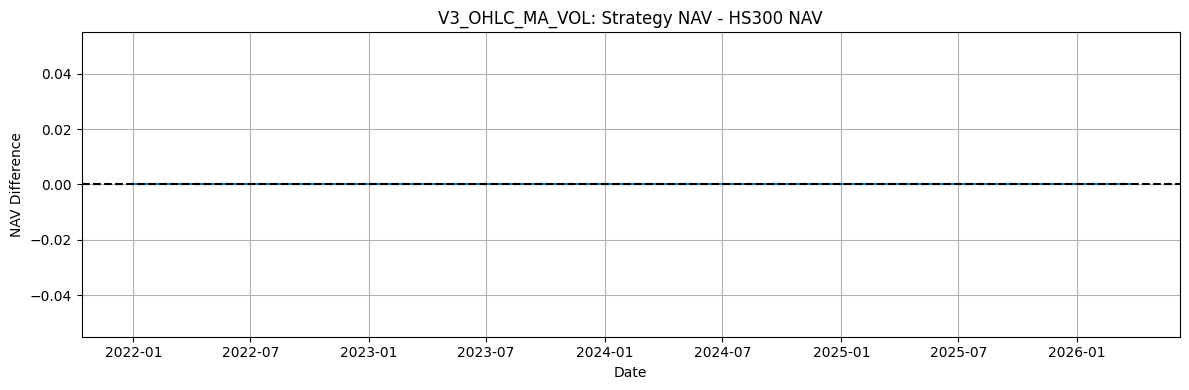


 ############################## V4_CANDLE_MA_VOL ##############################


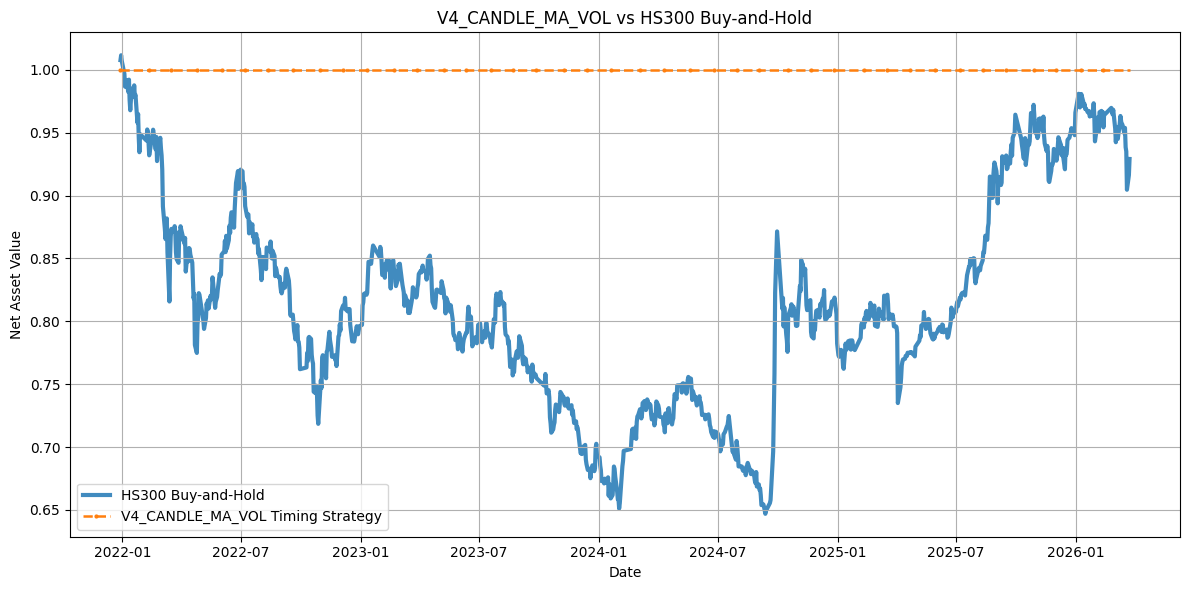

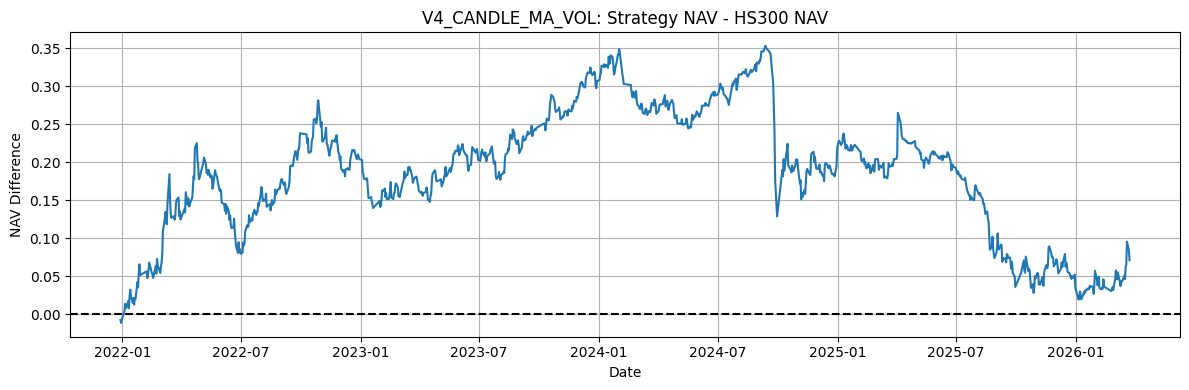


 ############################## V5_HIGHRES_OHLC_MA_VOL ##############################


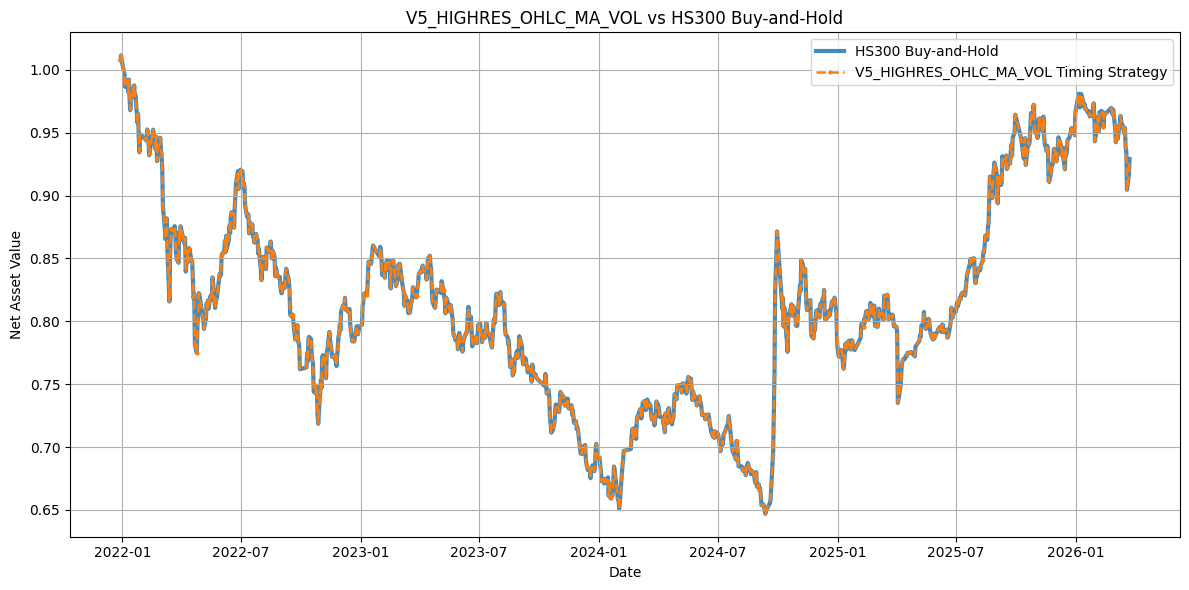

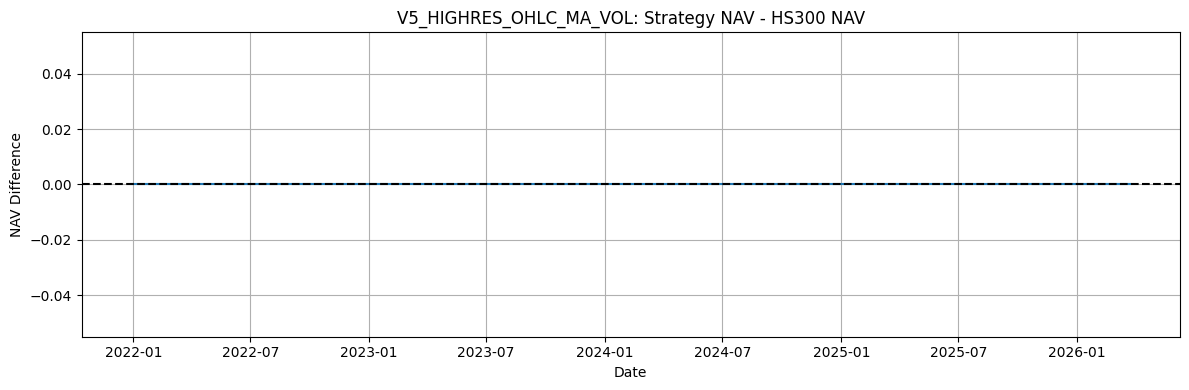


 ############################## V6_VOL30_OHLC_MA_VOL ##############################


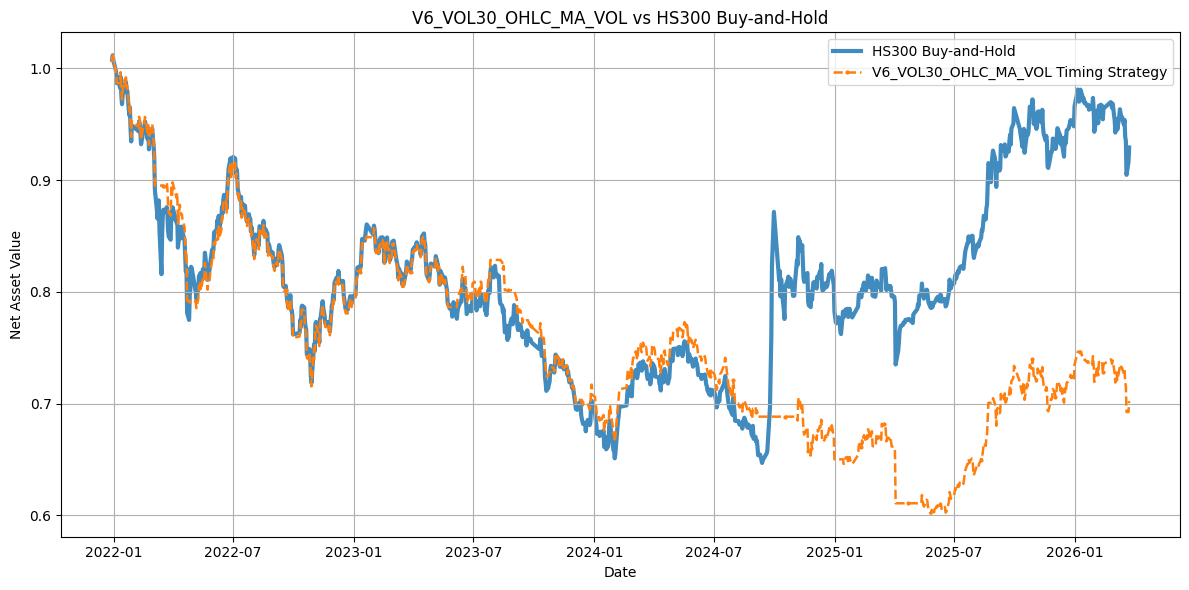

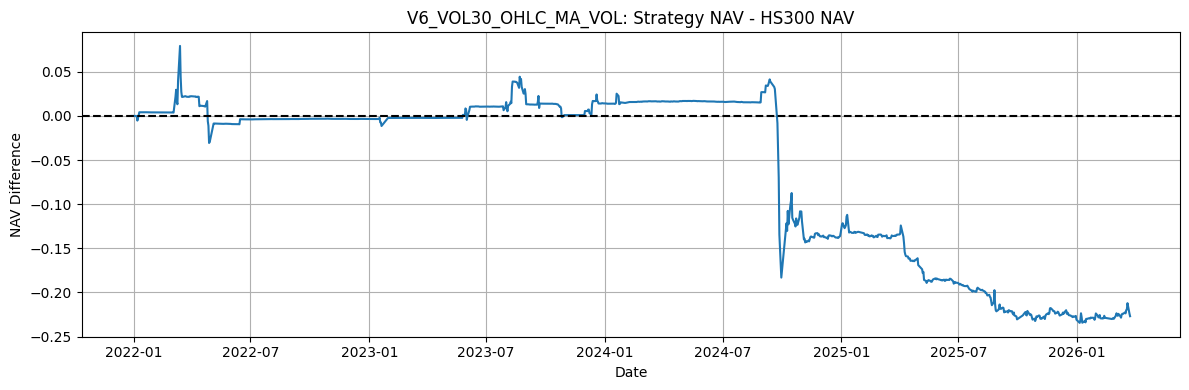

In [ ]:
# ============================================================
# 11. Individual plots
# ============================================================
for v in variants:
    print("\n", "#" * 30, v, "#" * 30)
    plot_strategy_vs_hs300_visible(backtests[v], v)

## Compare all rendering variants on one chart

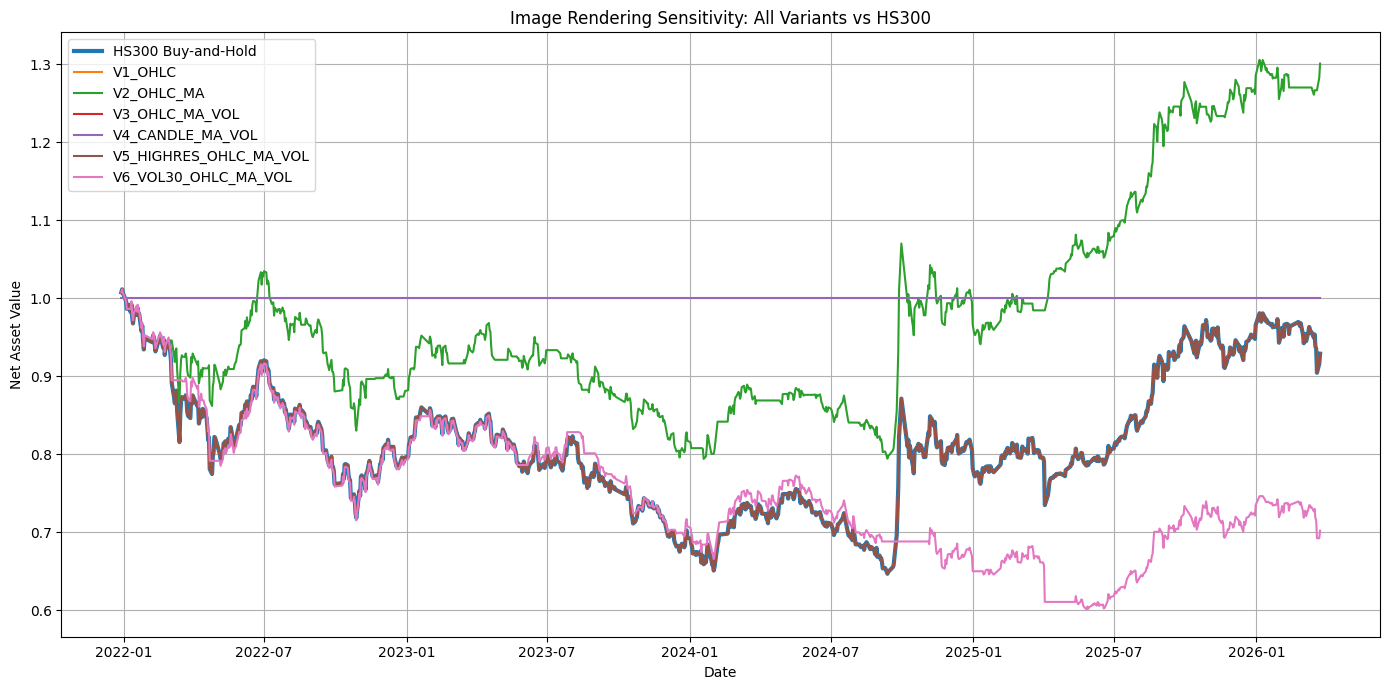

In [ ]:
# ============================================================
# 12. All variants vs HS300 on one chart
# ============================================================
plt.figure(figsize=(14, 7))
base = backtests[variants[0]]
plt.plot(base["date"], base["buy_hold_nav"], label="HS300 Buy-and-Hold", linewidth=3)

for v in variants:
    plt.plot(backtests[v]["date"], backtests[v]["strategy_nav"], label=v, linewidth=1.5)

plt.title("Image Rendering Sensitivity: All Variants vs HS300 (5-Day Silent Holding Rule)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Visual difference from the previous notebook

The previous notebook used a sparser visual design:

- the moving average was drawn as isolated points,
- it was not connected into a continuous line,
- the volume intensity was lower,
- the final image was visually more sparse.

This notebook changes those drawing details:

- the moving average is connected as a continuous curve,
- volume bars are brighter,
- in candlestick variants the moving-average line is even more visually prominent,
- the image contains many more non-zero pixels.

So this notebook is not just a tiny cosmetic change.  
It changes the visual balance between the main OHLC structure and the auxiliary information.


## Visual difference from the previous notebook

The previous notebook used a sparser visual design:

- the moving average was drawn as isolated points,
- it was not connected into a continuous line,
- the volume intensity was lower,
- the final image was visually more sparse.

This notebook changes those drawing details:

- the moving average is connected as a continuous curve,
- volume bars are brighter,
- in candlestick variants the moving-average line is even more visually prominent,
- the image contains many more non-zero pixels.

So this notebook is not just a tiny cosmetic change.  
It changes the visual balance between the main OHLC structure and the auxiliary information.


#### Summary

The result from the previous notebook suggests that, under a relatively sparse image representation, the model can focus more effectively on the core OHLC price structure. In that design, the moving average is only a light auxiliary signal and the volume area has lower visual weight, so the image remains cleaner and more price-centered.

By contrast, the current notebook changes only a few rendering details, but those details substantially alter the visual structure of the image. For example, the moving average is changed from isolated points to a connected line, and the volume area becomes brighter and more visually dominant. These changes give the auxiliary information much more visual influence, which can weaken the role of the OHLC structure itself.

The difference in performance between the two notebooks shows that, for a 2D CNN, image rendering is not a trivial implementation detail. It can directly shape what the model pays attention to and therefore materially affect the final trading results.


## Visual difference from the previous notebook

The previous notebook used a sparser visual design:

- the moving average was drawn as isolated points,
- it was not connected into a continuous line,
- the volume intensity was lower,
- the final image was visually more sparse.

This notebook changes those drawing details:

- the moving average is connected as a continuous curve,
- volume bars are brighter,
- in candlestick variants the moving-average line is even more visually prominent,
- the image contains many more non-zero pixels.

So this notebook is not just a tiny cosmetic change.  
It changes the visual balance between the main OHLC structure and the auxiliary information.
